# Notebook 3 - Elaboración del segundo modelo

## Objetivo
Este notebook implementa y evalúa una CNN según las especificaciones del taller.

## Flujo
1. Cargar particiones generadas en el notebook 1.
2. Preprocesar imágenes.
3. Construir el modelo.
4. Entrenar.
5. Evaluar con accuracy, precision, recall, f1-score y matriz de confusión.


In [1]:
# Instalar dependencias necesarias para el taller. También se puede con uv sync:
# !pip install -q tensorflow scikit-learn pandas matplotlib seaborn pillow


In [2]:
import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

BASE_DIR = Path.cwd().parent
ARTIFACTS_DIR = BASE_DIR / "data" / "artifacts"
RESULTS_DIR = BASE_DIR / "results"
RESULTS_DIR.mkdir(exist_ok=True)

print("TensorFlow:", tf.__version__)
print("Artifacts:", ARTIFACTS_DIR)


TensorFlow: 2.21.0
Artifacts: c:\Users\sebas\Desktop\Repositorios\1. DL\DL_Taller2\data\artifacts


In [3]:
train_df = pd.read_csv(ARTIFACTS_DIR / "train_split.csv")
test_df = pd.read_csv(ARTIFACTS_DIR / "test_split.csv")

with open(ARTIFACTS_DIR / "class_mapping.json", "r", encoding="utf-8") as f:
    mapping = json.load(f)

classes = mapping["classes"]
num_classes = len(classes)

print("Train:", train_df.shape)
print("Test:", test_df.shape)
print("Número de clases:", num_classes)


Train: (5078, 4)
Test: (1270, 4)
Número de clases: 10


## Decisión de hiperparámetros de entrenamiento
El taller permite:
- `epochs`: entre 1 y 50
- `batch size`: 1, 2, 4, 16, 32 o 64

En este desarrollo se usa inicialmente:
- `epochs = 15`
- `batch_size = 32`

**Justificación**:
- Batch size 32 suele ofrecer un buen equilibrio entre estabilidad del gradiente y uso de memoria.
- 15 épocas permiten observar convergencia inicial sin exceder tiempo de entrenamiento.
- Si el entrenamiento mejora todavía al final, se puede aumentar el número de épocas.


In [4]:
IMG_SIZE = (64, 64)
BATCH_SIZE = 32
EPOCHS = 15
AUTOTUNE = tf.data.AUTOTUNE


In [5]:
def load_and_preprocess_image(filepath, label):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, tf.cast(label, tf.int32)

def build_dataset(df, batch_size=32, training=False):
    ds = tf.data.Dataset.from_tensor_slices((df["filepath"].values, df["label"].values))
    ds = ds.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

train_ds = build_dataset(train_df, batch_size=BATCH_SIZE, training=True)
test_ds = build_dataset(test_df, batch_size=BATCH_SIZE, training=False)


## Arquitectura del modelo 2

- Conv2D con **48 filtros**, kernel **3x3**, `padding='same'`, activación **ReLU**
- MaxPooling **2x2**
- Conv2D con **96 filtros**, kernel **3x3**, `padding='same'`, activación **ReLU**
- MaxPooling **2x2**
- Flatten
- Dense **100** con **ReLU**
- Dense **100** con **ReLU**
- Salida `softmax`

In [6]:
model = keras.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    layers.Conv2D(
        filters=48,
        kernel_size=(3, 3),
        strides=1,
        padding="same",
        activation="relu"
    ),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(
        filters=96,
        kernel_size=(3, 3),
        strides=1,
        padding="same",
        activation="relu"
    ),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(100, activation="relu"),
    layers.Dense(100, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [7]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 48)     │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 96)     │        41,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 24576)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │     2,457,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,511,722 (9.58 MB)

 Trainable params: 2,511,722 (9.58 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    )
]

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 14s 74ms/step - accuracy: 0.7834 - loss: 0.7090 - val_accuracy: 0.9110 - val_loss: 0.3296
Epoch 2/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 13s 77ms/step - accuracy: 0.9122 - loss: 0.3017 - val_accuracy: 0.9291 - val_loss: 0.2583
Epoch 3/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 13s 75ms/step - accuracy: 0.9456 - loss: 0.1971 - val_accuracy: 0.9417 - val_loss: 0.2435
Epoch 4/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 13s 73ms/step - accuracy: 0.9579 - loss: 0.1492 - val_accuracy: 0.9441 - val_loss: 0.2041
Epoch 5/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 13s 73ms/step - accuracy: 0.9707 - loss: 0.1086 - val_accuracy: 0.9433 - val_loss: 0.2055
Epoch 6/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 13s 76ms/step - accuracy: 0.9762 - loss: 0.0835 - val_accuracy: 0.9520 - val_loss: 0.1952
Epoch 7/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 13s 73ms/step - accuracy: 0.9764 - loss: 0.0795 - val_accuracy: 0.9575 - val_loss: 0.1824
Epoch 8/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 13s 73ms/step - accuracy: 0.9846 - loss: 0.0553 - 

In [9]:
history_df = pd.DataFrame(history.history)
display(history_df.head())


,accuracy,loss,val_accuracy,val_loss
0,0.783379,0.709030,0.911024,0.329572
1,0.912170,0.301720,0.929134,0.258342
2,0.945648,0.197089,0.941732,0.243504
3,0.957857,0.149204,0.944094,0.204052
4,0.970658,0.108568,0.943307,0.205461


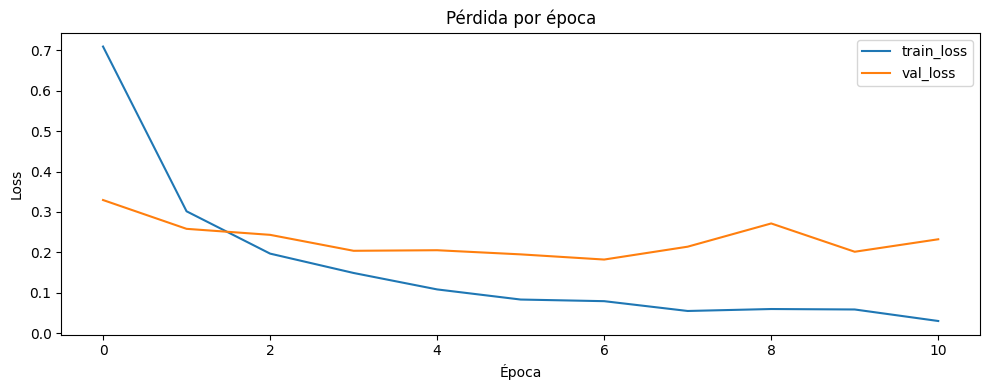

In [10]:
plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Pérdida por época")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()


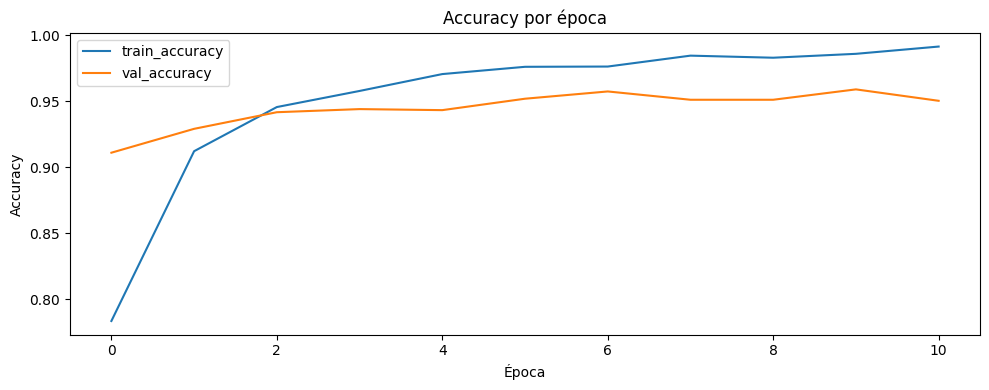

In [11]:
plt.figure(figsize=(10, 4))
plt.plot(history.history["accuracy"], label="train_accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.title("Accuracy por época")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()


In [12]:
y_true = test_df["label"].values
y_prob = model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_prob, axis=1)

acc = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average="weighted", zero_division=0
)

metrics_df = pd.DataFrame([{
    "accuracy": acc,
    "precision_weighted": precision,
    "recall_weighted": recall,
    "f1_weighted": f1
}])
display(metrics_df)


40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step


,accuracy,precision_weighted,recall_weighted,f1_weighted
0,0.95748,0.958918,0.95748,0.957671


In [13]:
report = classification_report(
    y_true, y_pred, target_names=classes, zero_division=0, output_dict=True
)
report_df = pd.DataFrame(report).transpose()
display(report_df.head(15))


,precision,recall,f1-score,support
GuideSign,0.966942,0.947368,0.957055,247.00000
M1,0.803571,0.865385,0.833333,52.00000
M4,0.976155,0.970370,0.973254,675.00000
M5,0.897959,0.977778,0.936170,45.00000
M6,0.833333,0.892857,0.862069,28.00000
M7,0.989691,0.969697,0.979592,99.00000
P1,0.896552,0.981132,0.936937,53.00000
P10_50,1.000000,1.000000,1.000000,20.00000
P12,1.000000,0.750000,0.857143,20.00000
W1,0.937500,0.967742,0.952381,31.00000


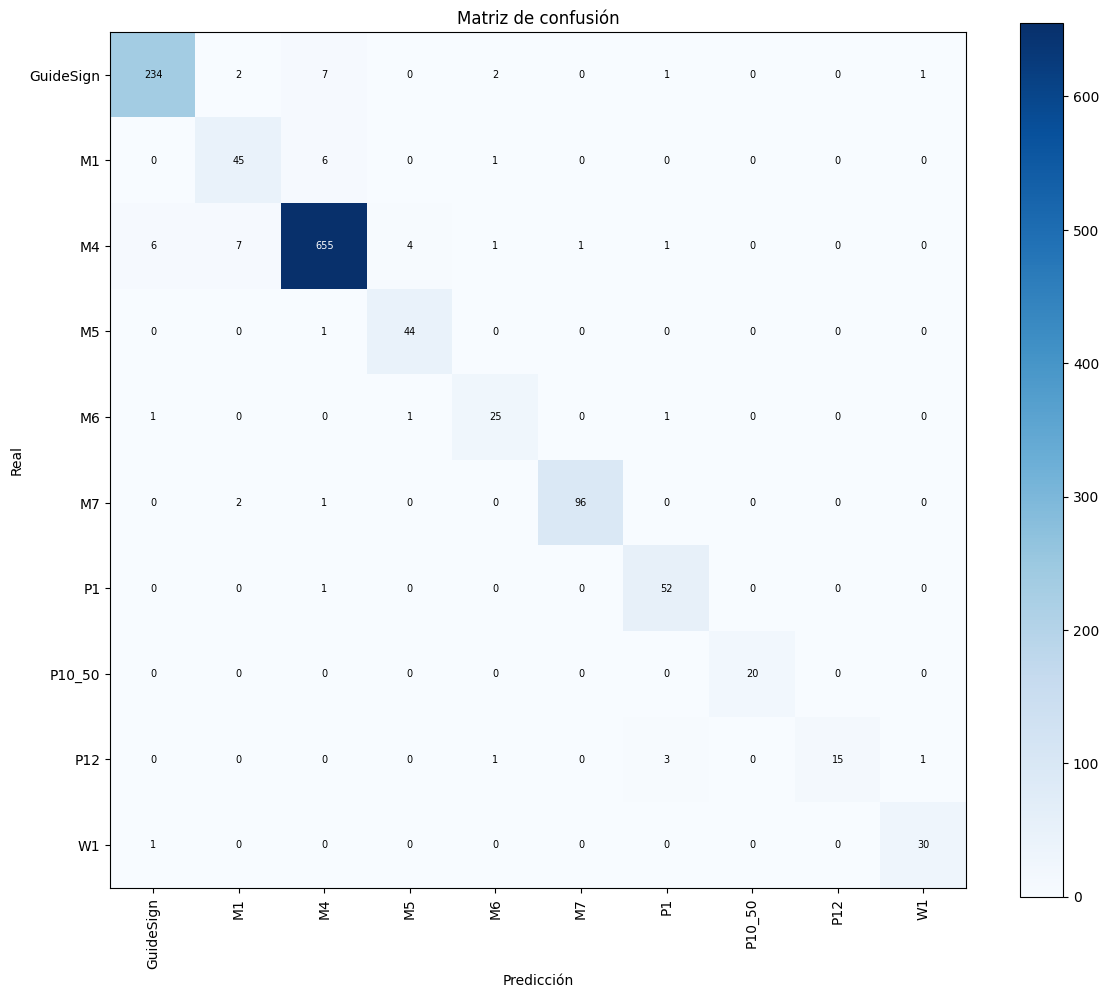

In [14]:
cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(classes)))

# Visualizar la matriz de confusión con números y etiquetas reales de clase
plt.figure(figsize=(12, 10))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Matriz de confusión")
plt.colorbar()

class_labels = [str(c) for c in classes]
tick_marks = np.arange(len(class_labels))
plt.xticks(tick_marks, class_labels, rotation=90)
plt.yticks(tick_marks, class_labels)

# Escribir el número de predicciones en cada celda
thresh = cm.max() / 2.0 if cm.size else 0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, f"{cm[i, j]}",
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black",
            fontsize=7
        )

plt.xlabel("Predicción")
plt.ylabel("Real")
plt.tight_layout()
plt.show()


In [15]:
history_df.to_csv(RESULTS_DIR / "model2_history.csv", index=False)
metrics_df.to_csv(RESULTS_DIR / "model2_metrics.csv", index=False)
report_df.to_csv(RESULTS_DIR / "model2_classification_report.csv")
np.save(RESULTS_DIR / "model2_confusion_matrix.npy", cm)
model.save(RESULTS_DIR / "model2_model.keras")

print("Resultados guardados en:", RESULTS_DIR)


Resultados guardados en: c:\Users\sebas\Desktop\Repositorios\1. DL\DL_Taller2\results
